# Urban Mobility & Economic Performance Analysis in Latin America
### Data Analysis Project with Python, Pandas & Data Visualization

**Author:** David Anampa

This project explores the relationship between urban mobility indicators and economic performance across major Latin American cities using Python-based data analysis workflows.

## Project Overview

This analysis evaluates how urban mobility patterns relate to economic indicators in major Latin American cities. The project combines traffic and economic datasets to identify trends associated with congestion, productivity, unemployment, pollution, and population density.

The workflow includes:

- Data exploration and validation
- Data cleaning and preprocessing
- Feature engineering
- Aggregation and statistical analysis
- Data visualization
- Final dataset export and conclusions

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 1. Data Loading & Initial Exploration

The first stage focuses on importing both datasets and validating their structure, data types, and overall quality before preprocessing.

In [ ]:

# importar librerías
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:

# cargar archivos
# load files
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')


In [ ]:
# mostrar las primeras 5 filas de traffic
# show the first 5 rows of traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
# show the first 5 rows of eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


## 2. Data Cleaning & Preparation

To ensure analytical consistency, the datasets were cleaned and standardized. This process included handling data types, renaming columns, correcting formatting inconsistencies, and validating missing values.

In [ ]:
# Examinar la estructura de traffic
# Examine the structure of traffic
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

### Initial Observations — Traffic Dataset

Key findings during the initial inspection:

- `UpdateTimeUTC` and `UpdateTimeUTCWeekAgo` were stored as string objects instead of datetime values.
- Several columns required type conversion for time-based analysis.
- The dataset contained multiple records per city, requiring aggregation in later stages.

In [ ]:
# Examinar la estructura de eco
# Examine the structure of eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


### Initial Observations — Economic Dataset

Key findings during the initial inspection:

- Economic indicators such as GDP per capita, unemployment rate, pollution index, and population size were stored as object types.
- Numeric formatting inconsistencies required cleaning and conversion.
- No major missing-value issues were detected during the audit.

### Column Standardization

Column names were standardized to improve readability, maintain consistency, and simplify dataset merging operations.

In [ ]:

# Estandarizar los nombres de las columnas de traffic
# Standardize the column names of traffic
traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_in_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per_10kms_mins',
    'MinsDelay': 'mins_delay'
})

# verificar cambios
# verify changes
traffic.columns


Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
# Standardize the column names of eco
eco = eco.rename(columns={
    'Year': 'year',
    'City': 'city',
    'Country': 'country',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_pct',
    'PM2.5 (μg/m³)': 'pm2.5_(μg/m³)',
    'Population (M)': 'population_m'
})
# verificar cambios
# verify changes
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm2.5_(μg/m³)', 'population_m'],
      dtype='object')

### Formatting Numerical & Date Variables

Date columns were converted into proper datetime formats, while numerical indicators were cleaned and transformed into numeric data types for statistical analysis and visualization.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
# Convert traffic columns to datetime type using pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])

# verificar el cambio
# verify the change
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
# Clean separators and convert numerical columns in eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
# Calculate the total population in absolute units (Multiply * 1000000)
eco['population_m'] = eco['population_m'] * 1000000

# verificar el cambio
# verify the change
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm2.5_(μg/m³)     30 non-null     object 
 6   population_m      30 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.8+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_(μg/m³),population_m
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13600000.0


## 3. Feature Engineering & Filtering

A new year variable was extracted from the datetime fields to isolate the most recent records and focus the analysis on 2024 data.

In [ ]:
# Extraer el año de las fechas en update_time_utc
# Extract the year from dates in update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
# Verify change
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:

# Filtra los registros del año 2024
# Filter the records from the year 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
# Review new dataframes
display(traffic_2024.head())
display(eco_2024.head())



,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_(μg/m³),population_m
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3900000.0


## 4. Mobility Data Aggregation & Analysis

Because the traffic dataset contained multiple observations per city, annual averages were calculated to generate a cleaner city-level analytical dataset.

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
# Calculate average traffic by city, country, and year

traffic_city_year_2024 = (traffic_2024.groupby(['city', 'country', 'year'])[
        ['jams_delay', 'traffic_index_live', 'jams_length_in_kms',
         'jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins',
         'travel_time_historic_per_10kms_mins']
    ]
    .agg('mean')
    .reset_index()
)
# Mostrar resultado
# Show results
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


## Preliminary Analysis

At this stage, the aggregated traffic metrics allow for an initial comparison between cities with higher congestion levels and those with more efficient mobility patterns.

In [ ]:
# Resultado preliminar
# Preliminary result
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


### Key Observation

Mexico City presented the highest average traffic congestion time among the analyzed cities.

## 5. Dataset Integration

The mobility and economic datasets were merged into a unified analytical table to evaluate potential relationships between traffic conditions and economic performance indicators.

In [ ]:

# Seleccionar columnas clave de tráfico y economía
# Select key traffic and economics columns
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']
right_cols = ['city','year','city_gdp_capita','unemployment_pct','population_m']

# Usar .copy() para crear los dos nuevos datasets reducidos
# Use .copy() to create the two new reduced datasets
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
# Merge datasets
merged = traffic_2024_small.merge(eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
# Show first 5 rows
merged.head(5)


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,population_m
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,3700000.0


## 6. Data Visualization & Relationship Analysis

Visual exploration techniques were applied to identify patterns, correlations, and outliers across mobility and economic indicators.

The visualizations focus on:

- Traffic congestion distribution
- GDP per capita comparisons
- Pollution and mobility relationships
- Cross-city economic variation

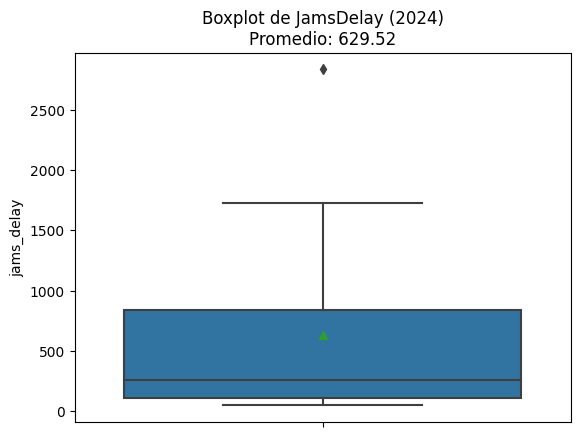

In [ ]:

# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# Create a boxplot to observe the behavior of the JamsDelay congestion minutes

sns.boxplot(data=merged, y='jams_delay', showmeans=True)

# Obtener promedio para mostrarlo en título
# Get average to display in title
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()




Text(0, 0.5, 'Número de Ciudades')

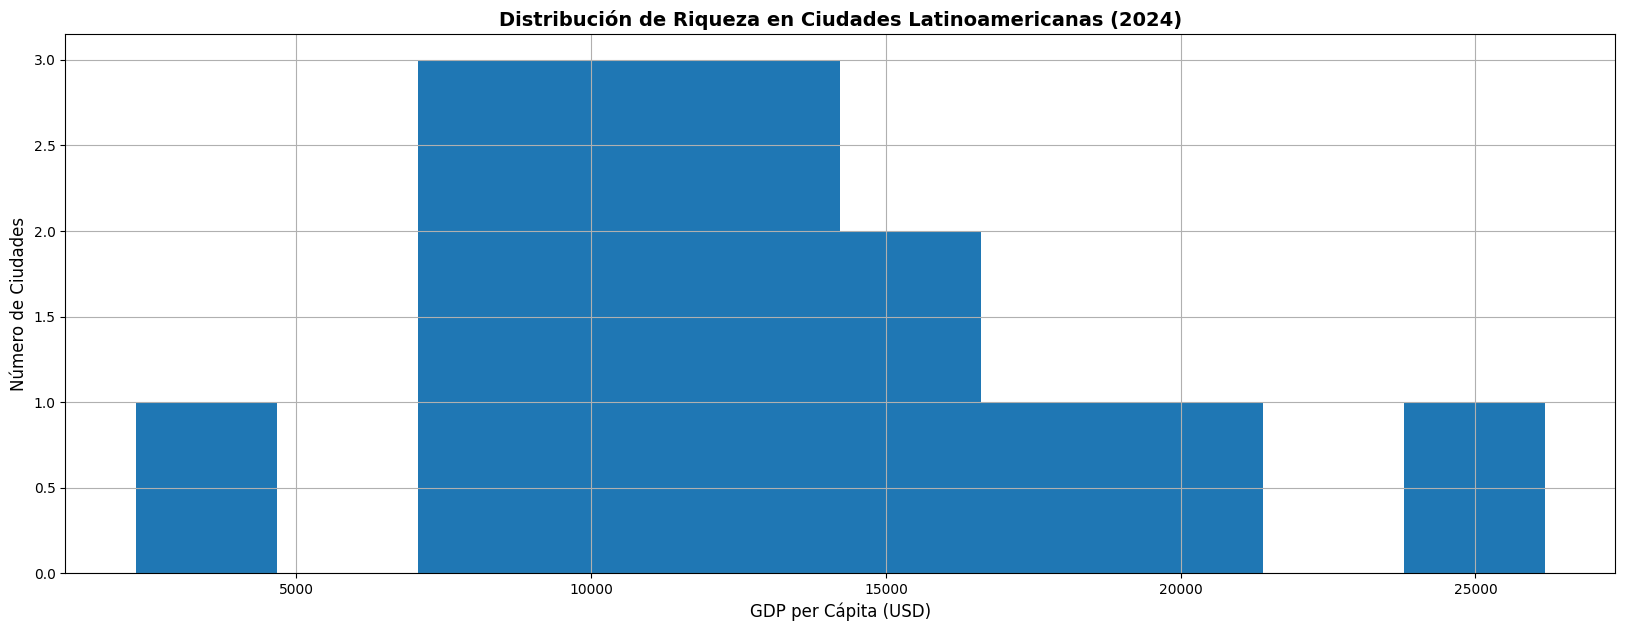

In [ ]:
# Histograma de city_gdp_capita
# Histogram of city_gdp_capita
merged['city_gdp_capita'].hist(bins=10, figsize=(20, 7))
plt.title('Distribución de Riqueza en Ciudades Latinoamericanas (2024)', fontsize=14, fontweight='bold')
plt.xlabel('GDP per Cápita (USD)', fontsize=12)
plt.ylabel('Número de Ciudades', fontsize=12)

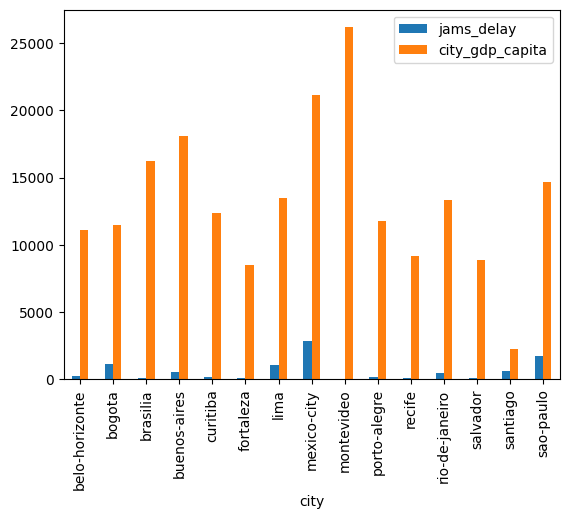

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
# Bar chart to compare jams_delay and city_gdp_capita by city
merged.plot( x='city', y=['jams_delay', 'city_gdp_capita'], kind='bar')
plt.xticks(rotation=90)
plt.show()

## Analytical Interpretation

The following section summarizes the main observations identified during the visual analysis phase.

### Findings

The analysis does not reveal a strong direct relationship between GDP per capita and traffic congestion. Results vary considerably across cities, suggesting that congestion levels are influenced by multiple structural and urban factors beyond economic output alone.

## 7. Final Export & Documentation

The cleaned analytical dataset was exported for future reporting, dashboard creation, and portfolio presentation purposes.

In [ ]:
# Exporta el dataset final como CSV
# Export the final dataset as CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

## Project Deliverables

- Complete Jupyter Notebook with analysis workflow
- Cleaned analytical dataset (`CSV`)
- Executive summary and findings
- Visualizations for portfolio presentation

# Executive Summary

## Objective
This project analyzes the relationship between urban mobility and economic performance across major Latin American cities using traffic and socioeconomic indicators.

## Methodology
The workflow included data cleaning, preprocessing, aggregation, exploratory analysis, visualization, and dataset integration using Python and the Pandas ecosystem.

## Main Findings
- Traffic congestion levels vary significantly across cities.
- Higher GDP per capita does not necessarily correlate with lower congestion.
- Urban mobility appears to be influenced by multiple demographic and structural variables.

## Conclusion
The project demonstrates a complete end-to-end data analysis workflow, from raw data preparation to business-oriented analytical insights and visual storytelling.